In [10]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import time

print("All packages loaded!")

All packages loaded!


In [11]:
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    n_classes=3,
    n_clusters_per_class=2,
    class_sep=0.5,
    random_state=42
)

feature_names = [f'feature_{i}' for i in range(20)]
class_names = ['class_0', 'class_1', 'class_2']

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

train_df, test_df = train_test_split(df, test_size=0.3, random_state=42)

X_train = train_df.drop('target', axis=1)
y_train = train_df['target']
X_test = test_df.drop('target', axis=1)
y_test = test_df['target']

print(f"Train size: {len(train_df)}")
print(f"Test size:  {len(test_df)}")
print(f"Features:   {X_train.shape[1]}")
print(f"Classes:    {class_names}")

Train size: 700
Test size:  300
Features:   20
Classes:    ['class_0', 'class_1', 'class_2']


In [33]:
models = {
    'KNN': KNeighborsClassifier(
        n_neighbors=5
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
        eval_metric='mlogloss',
        verbosity=0
    )
}

results = {}

print("=" * 60)
print("MODEL COMPARISON: KNN vs RandomForest vs XGBoost")
print("=" * 60)

for name, model in models.items():
    # Time the training
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    # Time prediction
    start = time.time()
    predictions = model.predict(X_test)
    predict_time = time.time() - start

    accuracy = accuracy_score(y_test, predictions)
    results[name] = {
        'model': model,
        'predictions': predictions,
        'accuracy': accuracy,
        'train_time': train_time,
        'predict_time': predict_time
    }

    print(f"\n{name}")
    print("-" * 40)
    print(f"Accuracy:      {accuracy*100:.1f}%")
    print(f"Train time:    {train_time*1000:.1f}ms")
    print(f"Predict time:  {predict_time*1000:.1f}ms")
    print(f"\nClassification Report:")
    print(classification_report(y_test, predictions, target_names=class_names))

print("=" * 60)
print("SUMMARY")
print("=" * 60)
for name, result in results.items():
    bar = "█" * int(result['accuracy'] * 40)
    print(f"{name:15} {result['accuracy']*100:.1f}% {bar}")

winner = max(results, key=lambda x: results[x]['accuracy'])
print(f"\nWINNER: {winner} with {results[winner]['accuracy']*100:.1f}%")
print("=" * 60)

MODEL COMPARISON: KNN vs RandomForest vs XGBoost

KNN
----------------------------------------
Accuracy:      66.7%
Train time:    1.2ms
Predict time:  6.6ms

Classification Report:
              precision    recall  f1-score   support

     class_0       0.61      0.74      0.67        98
     class_1       0.75      0.71      0.73       102
     class_2       0.65      0.55      0.59       100

    accuracy                           0.67       300
   macro avg       0.67      0.67      0.66       300
weighted avg       0.67      0.67      0.67       300


RandomForest
----------------------------------------
Accuracy:      61.7%
Train time:    85.3ms
Predict time:  3.0ms

Classification Report:
              precision    recall  f1-score   support

     class_0       0.51      0.59      0.55        98
     class_1       0.65      0.67      0.66       102
     class_2       0.71      0.59      0.64       100

    accuracy                           0.62       300
   macro avg       0.6

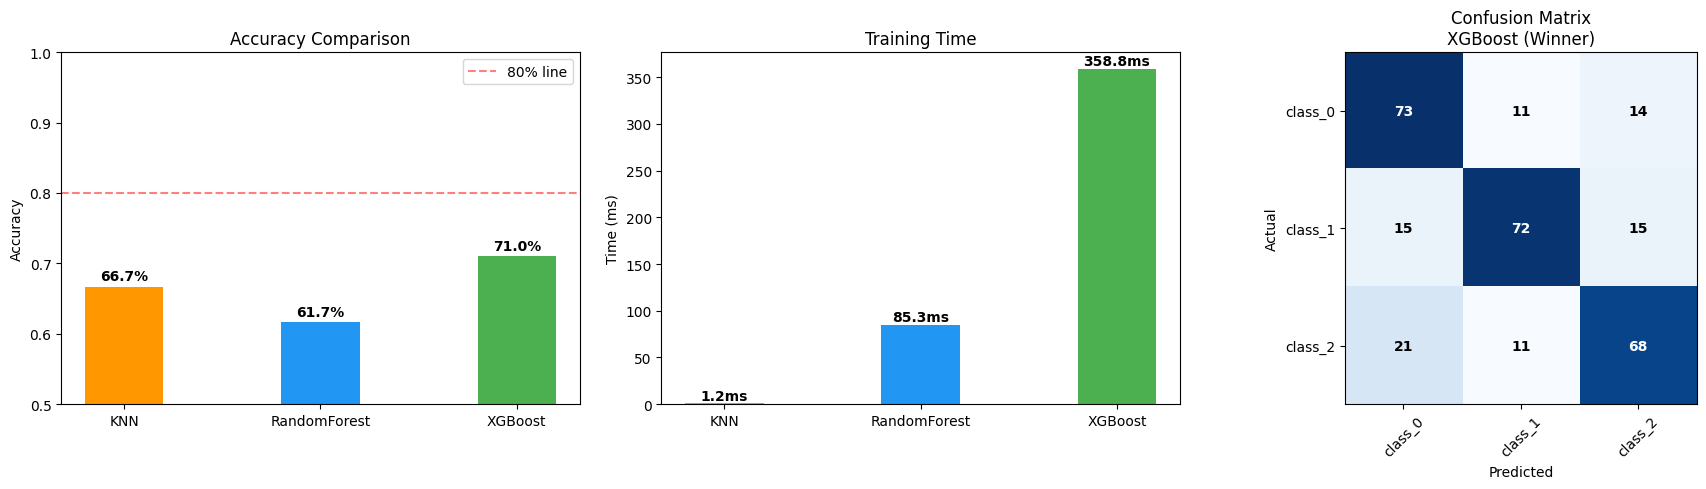

✓ Chart saved as model_comparison.png


In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1 - Accuracy comparison
ax1 = axes[0]
names = list(results.keys())
accuracies = [results[n]['accuracy'] for n in names]
colors = ['#FF9800', '#2196F3', '#4CAF50']
bars = ax1.bar(names, accuracies, color=colors, width=0.4)
ax1.set_ylim(0.5, 1.0)
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy Comparison')
ax1.axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='80% line')
ax1.legend()
for bar, acc in zip(bars, accuracies):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f'{acc*100:.1f}%',
        ha='center', va='bottom', fontweight='bold'
    )

# Chart 2 - Training time
ax2 = axes[1]
train_times = [results[n]['train_time']*1000 for n in names]
bars2 = ax2.bar(names, train_times, color=colors, width=0.4)
ax2.set_ylabel('Time (ms)')
ax2.set_title('Training Time')
for bar, t in zip(bars2, train_times):
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{t:.1f}ms',
        ha='center', va='bottom', fontweight='bold'
    )

# Chart 3 - Confusion matrix for winner
ax3 = axes[2]
winner_preds = results[winner]['predictions']
cm = confusion_matrix(y_test, winner_preds)
im = ax3.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax3.set_title(f'Confusion Matrix\n{winner} (Winner)')
ax3.set_xlabel('Predicted')
ax3.set_ylabel('Actual')
ax3.set_xticks([0,1,2])
ax3.set_yticks([0,1,2])
ax3.set_xticklabels(class_names, rotation=45)
ax3.set_yticklabels(class_names)
for i in range(3):
    for j in range(3):
        ax3.text(j, i, str(cm[i,j]),
                ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black',
                fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print("✓ Chart saved as model_comparison.png")

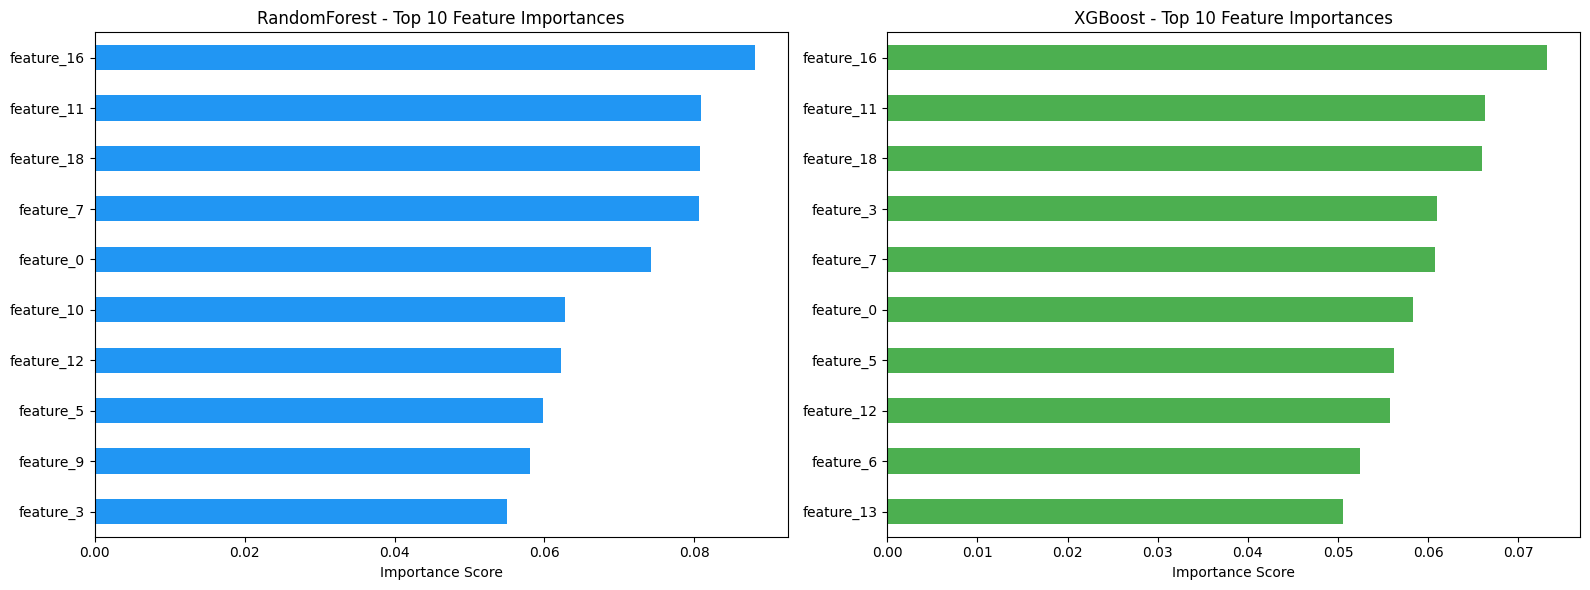

✓ Feature importance chart saved


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, model_name in enumerate(['RandomForest', 'XGBoost']):
    model = results[model_name]['model']
    importances = pd.Series(
        model.feature_importances_,
        index=feature_names
    ).sort_values(ascending=True).tail(10)

    ax = axes[idx]
    importances.plot(kind='barh', ax=ax, color=colors[idx+1])
    ax.set_title(f'{model_name} - Top 10 Feature Importances')
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('feature_importances.png', dpi=100, bbox_inches='tight')
plt.show()
print("✓ Feature importance chart saved")

In [36]:
import anthropic
import json

client = anthropic.Anthropic()

summary = {
    name: {
        "accuracy": f"{r['accuracy']*100:.1f}%",
        "train_time_ms": f"{r['train_time']*1000:.1f}ms",
        "predict_time_ms": f"{r['predict_time']*1000:.1f}ms"
    }
    for name, r in results.items()
}

response = client.messages.create(
    model="claude-sonnet-4-20250514",
    max_tokens=600,
    messages=[{
        "role": "user",
        "content": f"""
        I compared 3 ML models on a hard synthetic dataset:
        - 1000 samples, 20 features, 3 classes
        - class_sep=0.5 (overlapping classes)
        - 70/30 train/test split

        Results:
        {json.dumps(summary, indent=2)}

        Winner: {winner}

        Please explain:
        1. Why did {winner} win?
        2. What do the training times tell us?
        3. Which model would you use in production and why?
        4. How could we improve the worst performing model?
        Keep it concise and practical.
        """
    }]
)

print("Claude's analysis:")
print(response.content[0].text)

/var/folders/7t/7zjjrkz959zdhhc5fn1yfv0r0000gn/T/ipykernel_30552/471430861.py:15: DeprecationWarning: The model 'claude-sonnet-4-20250514' is deprecated and will reach end-of-life on June 15th, 2026.
Please migrate to a newer model. Visit https://docs.anthropic.com/en/docs/resources/model-deprecations for more information.
  response = client.messages.create(


Claude's analysis:
## Analysis

**1. Why XGBoost won:**
- **Gradient boosting handles complexity better** - XGBoost excels at finding non-linear decision boundaries in overlapping classes through sequential error correction
- **Feature interactions** - Better at capturing complex relationships between the 20 features
- **Regularization** - Built-in regularization prevents overfitting on this challenging dataset

**2. Training time insights:**
- **KNN (1.2ms)**: No actual training - just stores data
- **Random Forest (85.3ms)**: Moderate - builds multiple trees in parallel
- **XGBoost (358.8ms)**: Slowest - sequential boosting requires more computation

**3. Production choice: Random Forest**
Despite lower accuracy, RF offers the best balance:
- **Fast prediction** (3.0ms) - critical for real-time serving
- **Reasonable training time** for retraining
- **Only 9% accuracy drop** from XGBoost
- **More interpretable** than XGBoost

*Use XGBoost only if accuracy is paramount and latency isn

In [37]:
# Cell 7 - Tune XGBoost to push accuracy higher
from sklearn.model_selection import GridSearchCV

print("Tuning XGBoost...")

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

xgb = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss',
    verbosity=0
)

# Use 5-fold cross validation
grid_search = GridSearchCV(
    xgb,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,        # use all CPU cores on your M4!
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_*100:.1f}%")

# Test with best params
best_xgb = grid_search.best_estimator_
predictions = best_xgb.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"Test accuracy with tuned XGBoost: {accuracy*100:.1f}%")
print(f"Improvement: +{(accuracy - results['XGBoost']['accuracy'])*100:.1f}%")

Tuning XGBoost...
Fitting 5 folds for each of 243 candidates, totalling 1215 fits

Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.7}
Best CV accuracy: 69.7%
Test accuracy with tuned XGBoost: 74.0%
Improvement: +3.0%


In [38]:
# Cell 7 - Quick tuning
tuned_models = {
    'XGBoost_default': XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
        eval_metric='mlogloss',
        verbosity=0
    ),
    'XGBoost_deeper': XGBClassifier(
        n_estimators=300,       # more trees
        max_depth=7,            # deeper trees
        learning_rate=0.05,     # slower learning
        subsample=0.8,          # row sampling
        colsample_bytree=0.8,   # feature sampling
        random_state=42,
        eval_metric='mlogloss',
        verbosity=0
    ),
    'XGBoost_conservative': XGBClassifier(
        n_estimators=200,
        max_depth=3,            # shallow trees
        learning_rate=0.1,
        subsample=0.9,
        reg_alpha=0.1,          # L1 regularization
        reg_lambda=1.5,         # L2 regularization
        random_state=42,
        eval_metric='mlogloss',
        verbosity=0
    )
}

print("=" * 60)
print("XGBOOST TUNING COMPARISON")
print("=" * 60)

for name, model in tuned_models.items():
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    
    print(f"\n{name}")
    print(f"  Accuracy:   {accuracy*100:.1f}%")
    print(f"  Train time: {train_time*1000:.0f}ms")

print("=" * 60)

XGBOOST TUNING COMPARISON

XGBoost_default
  Accuracy:   71.0%
  Train time: 326ms

XGBoost_deeper
  Accuracy:   73.3%
  Train time: 1289ms

XGBoost_conservative
  Accuracy:   70.3%
  Train time: 413ms


In [39]:
#xg Boost optimized

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

# Split training data further for validation
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

print(f"Train sub size: {len(X_train_sub)}")
print(f"Validation size: {len(X_val)}")
print(f"Test size: {len(X_test)}")

# Optimized XGBoost
xgb_optimized = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.5,
    early_stopping_rounds=30,
    eval_metric='mlogloss',
    verbosity=0,
    n_jobs=-1
)

print("\nTraining optimized XGBoost...")
xgb_optimized.fit(
    X_train_sub, y_train_sub,
    eval_set=[(X_val, y_val)],
    verbose=False
)

predictions = xgb_optimized.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"\nResults:")
print(f"  Best iteration:      {xgb_optimized.best_iteration}")
print(f"  Optimized accuracy:  {accuracy*100:.1f}%")
print(f"  Previous best:       74.0%")
print(f"  Improvement:         +{(accuracy - 0.74)*100:.1f}%")

Train sub size: 560
Validation size: 140
Test size: 300

Training optimized XGBoost...

Results:
  Best iteration:      125
  Optimized accuracy:  68.7%
  Previous best:       74.0%
  Improvement:         +-5.3%


In [40]:
#Another twick  

from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
import numpy as np

# No validation split needed - cross_val uses all training data
xgb_cv = XGBClassifier(
    n_estimators=125,        # use best_iteration from previous run
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.5,
    eval_metric='mlogloss',
    verbosity=0,
    n_jobs=-1
)

# 5-fold cross validation on full training set
cv_scores = cross_val_score(
    xgb_cv, X_train, y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

print(f"CV scores:     {[f'{s*100:.1f}%' for s in cv_scores]}")
print(f"CV mean:       {cv_scores.mean()*100:.1f}%")
print(f"CV std:        {cv_scores.std()*100:.1f}%")

# Now train on ALL training data and test
xgb_cv.fit(X_train, y_train)
predictions = xgb_cv.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"\nFinal test accuracy: {accuracy*100:.1f}%")
print(f"Previous best:       74.0%")
print(f"Improvement:         +{(accuracy - 0.74)*100:.1f}%")

CV scores:     ['62.9%', '68.6%', '70.0%', '72.9%', '60.7%']
CV mean:       67.0%
CV std:        4.5%

Final test accuracy: 70.3%
Previous best:       74.0%
Improvement:         +-3.7%


More tweaking   

In [41]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
import time

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

xgb = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss',
    verbosity=0
)

grid_search = GridSearchCV(
    xgb,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Running grid search... (may take a few minutes)")
start = time.time()
grid_search.fit(X_train, y_train)
elapsed = time.time() - start

print(f"\nCompleted in {elapsed:.1f} seconds")
print(f"Best params:   {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_*100:.1f}%")

# Test accuracy
predictions = grid_search.best_estimator_.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"Test accuracy: {accuracy*100:.1f}%")

Running grid search... (may take a few minutes)
Fitting 5 folds for each of 243 candidates, totalling 1215 fits

Completed in 49.5 seconds
Best params:   {'colsample_bytree': 0.9, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.7}
Best CV score: 69.7%
Test accuracy: 74.0%


In [42]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
# grid_search = GridSearchCV(
#     xgb,
#     param_grid,
#     cv=5,
#     scoring='accuracy',
#     n_jobs=-1,        # use all CPU cores on your M4!
#     verbose=1
# )


# Use best params from grid search but add early stopping
xgb_best = XGBClassifier(
    **grid_search.best_params_,   # has all params
    eval_metric='mlogloss',        # add only what's missing
    verbosity=0,
    n_jobs=-1
)

# Need eval set for early stopping
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

xgb_best.fit(
    X_train_sub, y_train_sub,
    eval_set=[(X_val, y_val)],
    verbose=False
)

predictions = xgb_best.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"XGBoost with early stopping: {accuracy*100:.1f}%")
#print(f"Best iteration: {xgb_best.best_iteration}")



XGBoost with early stopping: 68.0%


In [43]:
import copy

# Get best params and modify slightly
best_params = grid_search.best_params_.copy()
print("Starting from:", best_params)

# Try variations around the best params
variations = [
    {**best_params, 'n_estimators': best_params['n_estimators'] * 2},
    {**best_params, 'learning_rate': best_params['learning_rate'] / 2},
    {**best_params, 'subsample': 0.9},
    {**best_params, 'colsample_bytree': 0.9},
    {**best_params, 'min_child_weight': 1},
]

print("\nTrying variations around best params:")
print("-" * 50)

best_so_far = 0.74
best_variation = None

for i, params in enumerate(variations):
    model = XGBClassifier(
        **params,
        eval_metric='mlogloss',
        verbosity=0,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    
    marker = "🏆" if accuracy > best_so_far else ""
    print(f"Variation {i+1}: {accuracy*100:.1f}% {marker}")
    
    if accuracy > best_so_far:
        best_so_far = accuracy
        best_variation = params

print("-" * 50)
print(f"Best so far: {best_so_far*100:.1f}%")
if best_variation:
    print(f"Best params: {best_variation}")
else:
    print("No improvement found — 74% may be the ceiling for this dataset")

Starting from: {'colsample_bytree': 0.9, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.7}

Trying variations around best params:
--------------------------------------------------
Variation 1: 72.7% 
Variation 2: 74.3% 🏆
Variation 3: 71.7% 
Variation 4: 72.0% 
Variation 5: 72.0% 
--------------------------------------------------
Best so far: 74.3%
Best params: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.7}


In [44]:
# New best params
new_best = {
    'colsample_bytree': 0.9,
    'learning_rate': 0.05,
    'max_depth': 7,
    'n_estimators': 100,
    'subsample': 0.7
}

# Try more trees since we slowed learning rate
# slower learning rate needs more trees to compensate
variations_2 = [
    {**new_best, 'n_estimators': 200},   # more trees
    {**new_best, 'n_estimators': 300},   # even more trees
    {**new_best, 'n_estimators': 500},   # lots of trees
    {**new_best, 'n_estimators': 200, 'max_depth': 5},   # more trees, shallower
    {**new_best, 'n_estimators': 300, 'max_depth': 5},   # more trees, shallower
    {**new_best, 'n_estimators': 200, 'subsample': 0.8}, # more trees, more data
    {**new_best, 'n_estimators': 200, 'learning_rate': 0.03}, # even slower
]

print("Trying variations from new baseline (74.3%):")
print("-" * 50)

best_so_far = 0.743
best_variation = None

for i, params in enumerate(variations_2):
    model = XGBClassifier(
        **params,
        eval_metric='mlogloss',
        verbosity=0,
        n_jobs=-1,
        random_state=42
    )
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)

    marker = "🏆" if accuracy > best_so_far else ""
    print(f"Variation {i+1}: {accuracy*100:.1f}% {marker} {params['n_estimators']} trees, depth={params['max_depth']}, lr={params['learning_rate']}")

    if accuracy > best_so_far:
        best_so_far = accuracy
        best_variation = params

print("-" * 50)
print(f"Best so far: {best_so_far*100:.1f}%")
if best_variation:
    print(f"Best params: {best_variation}")
else:
    print("74.3% appears to be the ceiling for this dataset!")

Trying variations from new baseline (74.3%):
--------------------------------------------------
Variation 1: 70.7%  200 trees, depth=7, lr=0.05
Variation 2: 72.7%  300 trees, depth=7, lr=0.05
Variation 3: 73.0%  500 trees, depth=7, lr=0.05
Variation 4: 72.0%  200 trees, depth=5, lr=0.05
Variation 5: 72.0%  300 trees, depth=5, lr=0.05
Variation 6: 74.3% 🏆 200 trees, depth=7, lr=0.05
Variation 7: 73.0%  200 trees, depth=7, lr=0.03
--------------------------------------------------
Best so far: 74.3%
Best params: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}


Deploy to aws sagemaker

In [30]:
import joblib
import boto3
import tarfile
import os

# Save the best model
best_params = {
    'colsample_bytree': 0.9,
    'learning_rate': 0.05,
    'max_depth': 7,
    'n_estimators': 200,
    'subsample': 0.8
}

final_model = XGBClassifier(
    **best_params,
    eval_metric='mlogloss',
    verbosity=0,
    n_jobs=-1,
    random_state=42
)

final_model.fit(X_train, y_train)

# Verify accuracy
predictions = final_model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"Final model accuracy: {accuracy*100:.1f}%")

# Save model
os.makedirs('model', exist_ok=True)
joblib.dump(final_model, 'model/model.joblib')
print("✓ Model saved locally")

Final model accuracy: 74.3%
✓ Model saved locally


In [47]:
# Package into tar.gz (SageMaker requirement)
with tarfile.open('model.tar.gz', 'w:gz') as tar:
    tar.add('model/model.joblib', arcname='model.joblib')

print("✓ Model packaged")

# Upload to S3
s3_client = boto3.client('s3', region_name='us-east-1')
s3_client.upload_file(
    'model.tar.gz',
    'mva-python-code-east',
    'synthetic/model/model.tar.gz'
)

print(f"✓ Model uploaded to s3://{'mva-python-code-east'}/synthetic/model/model.tar.gz")

✓ Model packaged
✓ Model uploaded to s3://mva-python-code-east/synthetic/model/model.tar.gz


In [14]:
# Create inference script
inference_script = '''
import joblib
import numpy as np
import os
import json

def model_fn(model_dir):
    model = joblib.load(os.path.join(model_dir, "model.joblib"))
    return model

def input_fn(request_body, request_content_type):
    """Handle both json and numpy formats"""
    if request_content_type == "application/json":
        data = json.loads(request_body)
        # handle both {"instances": [...]} and direct array
        if isinstance(data, dict):
            return np.array(data["instances"])
        return np.array(data)
    
    elif request_content_type == "application/x-npy":
        import io
        return np.load(io.BytesIO(request_body), allow_pickle=True)
    
    elif request_content_type == "text/csv":
        import io
        return np.loadtxt(io.StringIO(request_body), delimiter=",")
    
    raise ValueError(f"Unsupported content type: {request_content_type}")

def predict_fn(input_data, model):
    predictions = model.predict(input_data)
    probabilities = model.predict_proba(input_data)
    return {
        "predictions": predictions.tolist(),
        "probabilities": probabilities.tolist()
    }

def output_fn(prediction, content_type):
    return json.dumps(prediction)
'''

with open('scripts/inference.py', 'w') as f:
    f.write(inference_script)

print("✓ inference.py updated")

✓ inference.py updated


In [1]:
# Cell 1 - test boto3 basic connection
import boto3
print("boto3 imported")

sts = boto3.client('sts', region_name='us-east-1')
print("STS client created")

identity = sts.get_caller_identity()
print("Identity:", identity['Account'])

boto3 imported
STS client created
Identity: 806575638863


In [2]:
# Cell 2 - test S3 connection separately
import boto3

s3 = boto3.client('s3', region_name='us-east-1')
print("S3 client created")

# List buckets first
buckets = s3.list_buckets()
print("Buckets:", [b['Name'] for b in buckets['Buckets']])

S3 client created
Buckets: ['amazon-sagemaker-806575638863-us-east-1-4chcvutkr8789z', 'athamtech.com', 'cf-templates-qktrznz0olb3-us-east-1', 'cli-bucket-mva-1', 'cli-bucket-mva-2', 'data-analyst-mva', 'lambda-s3-mva', 'madhav-bedrock', 'madhav-s3-developer', 'mva-python-code-east', 'mva-spark3', 'mva5097-trivia-app-bucket', 'sagemaker-mva', 'sagemaker-us-east-1-806575638863']


In [3]:
# Cell 3 - check specific file
s3.head_object(
    Bucket='mva-python-code-east',
    Key='synthetic/model/model.tar.gz'
)
print("✓ Model found!")

✓ Model found!


In [4]:
from sagemaker.sklearn.model import SKLearnModel
import sagemaker
import boto3

# Fix 1 - specify region explicitly
region = 'us-east-1'
bucket = 'mva-python-code-east'
boto_session = boto3.Session(region_name=region)
session = sagemaker.Session(boto_session=boto_session)

# Fix 2 - get role manually instead of get_execution_role()
account_id = boto3.client('sts', region_name=region).get_caller_identity()['Account']
role = f"arn:aws:iam::{account_id}:role/SageMakerRole"

print(f"Account: {account_id}")
print(f"Role: {role}")
print(f"Model: s3://{bucket}/synthetic/model/model.tar.gz")

# Verify model exists in S3
s3 = boto3.client('s3', region_name=region)
try:
    s3.head_object(Bucket=bucket, Key='synthetic/model/model.tar.gz')
    print("✓ Model found in S3")
except Exception as e:
    print(f"✗ Model NOT found in S3: {e}")
    print("Run the model save and upload cells first!")

sagemaker.config INFO - Not applying SDK defaults from location: /Library/Application Support/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /Users/madhavathavale/Library/Application Support/sagemaker/config.yaml
Account: 806575638863
Role: arn:aws:iam::806575638863:role/SageMakerRole
Model: s3://mva-python-code-east/synthetic/model/model.tar.gz
✓ Model found in S3


In [7]:
from sagemaker.sklearn.model import SKLearnModel
import sagemaker
import boto3

region = 'us-east-1'
bucket = 'mva-python-code-east'
boto_session = boto3.Session(region_name=region)
session = sagemaker.Session(boto_session=boto_session)

# Your hardcoded role
role = 'arn:aws:iam::806575638863:role/SageMakerRole'

sklearn_model = SKLearnModel(
    model_data=f's3://{bucket}/synthetic/model/model.tar.gz',
    role=role,
    entry_point='inference.py',
    source_dir='scripts',      # requirements.txt is here
    framework_version='1.2-1',
    py_version='py3',
    sagemaker_session=session
)

print("Deploying...")
predictor = sklearn_model.deploy(
    initial_instance_count=1,
    instance_type='ml.t2.medium',
    endpoint_name='xgboost-synthetic-classifier-v2'
)

print(f"✓ Endpoint deployed: {predictor.endpoint_name}")

Deploying...
-------------------!✓ Endpoint deployed: xgboost-synthetic-classifier-v2


In [15]:
from sagemaker.predictor import Predictor
from sagemaker.serializers import JSONSerializer
from sagemaker.deserializers import JSONDeserializer

# Recreate predictor with JSON serializer
predictor = Predictor(
    endpoint_name='xgboost-synthetic-classifier-v2',
    sagemaker_session=session,
    serializer=JSONSerializer(),
    deserializer=JSONDeserializer()
)

# Now call with dict directly
test_samples = X_test.iloc[:5].values.tolist()
result = predictor.predict({"instances": test_samples})

print("Predictions:", result)

Predictions: {'predictions': [2, 0, 1, 0, 0], 'probabilities': [[0.1326754242181778, 0.10001901537179947, 0.7673055529594421], [0.3859690725803375, 0.26265454292297363, 0.35137635469436646], [0.13656964898109436, 0.8559707999229431, 0.007459497079253197], [0.7257264256477356, 0.029470404610037804, 0.24480316042900085], [0.9381512403488159, 0.030838096514344215, 0.031010674312710762]]}


In [16]:
import json

class_names = ['class_0', 'class_1', 'class_2']
true_labels = y_test.iloc[:5].values.tolist()

predictions = result['predictions']
probabilities = result['probabilities']

print("Results from AWS Endpoint:")
print("=" * 65)
print(f"{'Sample':<8} {'True':<12} {'Predicted':<12} {'Confidence':<12} {'Correct'}")
print("-" * 65)

for i, (true, pred, probs) in enumerate(zip(
    true_labels, predictions, probabilities
)):
    true_label = class_names[int(true)]
    pred_label = class_names[int(pred)]
    confidence = max(probs) * 100
    correct = "✓" if int(true) == int(pred) else "✗"
    print(f"{i+1:<8} {true_label:<12} {pred_label:<12} {confidence:<11.1f}% {correct}")

print("-" * 65)
correct_count = sum(1 for t, p in zip(true_labels, predictions) if int(t) == int(p))
print(f"Accuracy: {correct_count}/5 = {correct_count/5*100:.1f}%")

print("\nProbability breakdown:")
print("-" * 65)
for i, (pred, probs) in enumerate(zip(predictions, probabilities)):
    print(f"\nSample {i+1} → {class_names[int(pred)]}")
    for cls, prob in zip(class_names, probs):
        bar = "█" * int(prob * 30)
        print(f"  {cls}: {prob*100:5.1f}% {bar}")

Results from AWS Endpoint:
Sample   True         Predicted    Confidence   Correct
-----------------------------------------------------------------
1        class_2      class_2      76.7       % ✓
2        class_0      class_0      38.6       % ✓
3        class_0      class_1      85.6       % ✗
4        class_0      class_0      72.6       % ✓
5        class_0      class_0      93.8       % ✓
-----------------------------------------------------------------
Accuracy: 4/5 = 80.0%

Probability breakdown:
-----------------------------------------------------------------

Sample 1 → class_2
  class_0:  13.3% ███
  class_1:  10.0% ███
  class_2:  76.7% ███████████████████████

Sample 2 → class_0
  class_0:  38.6% ███████████
  class_1:  26.3% ███████
  class_2:  35.1% ██████████

Sample 3 → class_1
  class_0:  13.7% ████
  class_1:  85.6% █████████████████████████
  class_2:   0.7% 

Sample 4 → class_0
  class_0:  72.6% █████████████████████
  class_1:   2.9% 
  class_2:  24.5% ███████

